# Recall Decomposition Analysis

## Pipeline Overview

The typed composition search (TCS) pipeline selects tools in two stages:

1. **Entity classification** — an LLM predicts source and target types from the user query
   (e.g., "get pods for deployment X" → source=`Deployment`, target=`Pod`)
2. **Graph resolution** — BFS traverses the type composition graph to find a tool path
   connecting the source type to the target type

## Recall Decomposition

End-to-end recall can be decomposed by conditioning on whether the LLM predicted the
correct types. For any query, either the types are correct or they are wrong, so:

$$\text{Recall}_{e2e} = P(\text{types correct}) \cdot \text{Recall}_{\text{correct}} + P(\text{types wrong}) \cdot \text{Recall}_{\text{wrong}}$$

Where:
- $P(\text{types correct})$ = **TypeExact** — the fraction of queries where both source and
  target types match ground truth (measured by the `model-types` benchmark)
- $\text{Recall}_{\text{correct}}$ = **OracleRecall** — recall when ground-truth types are
  given to the graph (measured by the `graph-perfect` benchmark). This isolates graph
  quality from LLM accuracy.
- $\text{Recall}_{\text{wrong}}$ = **RecallWrong** — average recall on queries where the LLM
  predicted incorrect types. When wrong types are given, the graph traverses from the wrong
  starting node, so it may find completely wrong tools, partially overlapping tools, or
  (by coincidence) still-correct tools.

## The Simplified Assumption

If the graph only finds useful tools when types are exactly correct — i.e.,
$\text{Recall}_{\text{wrong}} \approx 0$ — the equation simplifies to:

$$\text{Recall}_{e2e} \approx \text{TypeExact} \times \text{OracleRecall}$$

This is an intuitive lower bound: end-to-end recall cannot exceed the product of how often
the LLM gets types right and how well the graph resolves correct types.

**Whether this assumption holds is an empirical question.** If wrong types happen to be
"close" in the graph (e.g., `Cluster→Pod` instead of `Deployment→Pod`), the traversal
may still pass through some correct tools, making $\text{Recall}_{\text{wrong}} > 0$.
This notebook validates the assumption and reports the full decomposition.

## What This Tells Us

The decomposition separates two independent sources of error:
- **Low TypeExact** → the LLM is the bottleneck (improve the classifier)
- **Low OracleRecall** → the graph is the bottleneck (improve graph coverage)
- **Large gap between predicted and actual** → the model is more nuanced than the
  decomposition captures (e.g., "partially wrong" types still help)

In [1]:
# === PARAMETERS ===
# Change these to filter the analysis.
# None = use all available data.

RESULTS_DIR = "../benchmarks/results"

MODELS = None            # e.g. ["qwen", "claude-haiku"]
DOMAINS = None           # e.g. ["k8s", "ansible"]

ORACLE_KEY = "graph-perfect"    # strategy with ground-truth types
TYPE_KEY = "model-types"        # strategy measuring LLM type prediction
E2E_KEY = "graph"               # end-to-end graph strategy
BASELINE_KEY = "baseline"       # text-based baseline
BASELINE_TOOLS_KEY = "baseline-tools"  # native tool-calling baseline

In [2]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Data Loading

In [3]:
results_dir = Path(RESULTS_DIR)

rows = []
query_rows = []

for f in sorted(results_dir.glob("*.json")):
    data = json.loads(f.read_text())
    meta = data["meta"]
    model, domain = meta["model"], meta["domain"]

    if MODELS and model not in MODELS:
        continue
    if DOMAINS and domain not in DOMAINS:
        continue

    for s in data["strategies"]:
        key = s.get("strategy_key", s.get("strategy", "?"))
        row = {
            "model": model,
            "domain": domain,
            "strategy": key,
            "precision": s.get("precision", 0),
            "recall": s.get("recall", 0),
            "f1": s.get("f1", 0),
            "hallucinated": s.get("hallucinated", 0),
            "avg_tools": s.get("avg_tools", 0),
            "total_tools": s.get("total_tools", 0),
            "pruning": s.get("pruning", 0),
            "latency_avg": s.get("latency_avg", 0),
            "avg_prompt_tokens": s.get("avg_prompt_tokens", 0),
            "n": s.get("n", 0),
            "path_found_pct": s.get("path_found_pct"),
            "source_accuracy": s.get("source_accuracy"),
            "target_accuracy": s.get("target_accuracy"),
            "exact_match_accuracy": s.get("exact_match_accuracy"),
        }
        rows.append(row)

        for q in s.get("per_query", []):
            query_rows.append({
                "model": model,
                "domain": domain,
                "strategy": key,
                **q,
            })

df = pd.DataFrame(rows)
qdf = pd.DataFrame(query_rows)

models = sorted(df["model"].unique())
domains = sorted(df["domain"].unique())
strategies = sorted(df["strategy"].unique())

print(f"Models:     {models}")
print(f"Domains:    {domains}")
print(f"Strategies: {strategies}")
print(f"\n{len(df)} strategy rows, {len(qdf)} per-query rows")

Models:     ['qwen']
Domains:    ['ansible', 'cicd', 'github', 'k8s']
Strategies: ['baseline', 'baseline-tools', 'graph', 'graph-perfect', 'graph-reverse-probs', 'model-types', 'retrieval']

28 strategy rows, 777 per-query rows


## 2. Validation

Check that the data has the strategies and fields needed for decomposition.

In [4]:
required_strategies = [ORACLE_KEY, TYPE_KEY, E2E_KEY]
warnings = []

for model in models:
    for domain in domains:
        subset = df[(df["model"] == model) & (df["domain"] == domain)]
        present = set(subset["strategy"])

        for req in required_strategies:
            if req not in present:
                warnings.append(f"MISSING {req} for {model}/{domain}")

        # Check query counts match across strategies
        counts = subset.set_index("strategy")["n"].to_dict()
        non_zero = {k: v for k, v in counts.items() if v > 0}
        if len(set(non_zero.values())) > 1:
            warnings.append(f"QUERY COUNT MISMATCH {model}/{domain}: {non_zero}")

        # Check oracle recall < 1.0
        oracle = subset[subset["strategy"] == ORACLE_KEY]
        if not oracle.empty:
            orc_rec = oracle.iloc[0]["recall"]
            if orc_rec < 1.0:
                warnings.append(f"NOTE: oracle recall < 1.0 for {model}/{domain} ({orc_rec:.2f}) — graph does not cover all queries")

# Check per-query fields needed for decomposition
if not qdf.empty:
    e2e_queries = qdf[qdf["strategy"] == E2E_KEY]
    if not e2e_queries.empty:
        has_pred_source = "predicted_source" in e2e_queries.columns and e2e_queries["predicted_source"].notna().any()
        has_exp_source = "expected_source" in e2e_queries.columns and e2e_queries["expected_source"].notna().any()
        if not has_pred_source or not has_exp_source:
            warnings.append(f"MISSING per-query type fields (predicted_source/expected_source) in {E2E_KEY} — cannot compute recall_wrong")

if warnings:
    print("Validation warnings:")
    for w in warnings:
        print(f"  - {w}")
else:
    print("All validations passed.")

Validation warnings:
  - NOTE: oracle recall < 1.0 for qwen/ansible (0.75) — graph does not cover all queries
  - NOTE: oracle recall < 1.0 for qwen/github (0.92) — graph does not cover all queries
  - NOTE: oracle recall < 1.0 for qwen/k8s (0.97) — graph does not cover all queries


## 3. Recall Decomposition

Computing all terms of the full equation for each model/domain combination:

| Term | Source | Meaning |
|------|--------|---------|
| **TypeExact** | `model-types` benchmark | P(both source and target types correct) |
| **OracleRecall** | `graph-perfect` benchmark | Recall with ground-truth types (graph quality) |
| **RecallWrong** | `graph` per-query data | Mean recall on queries with wrong predicted types |
| **Predicted(simple)** | TypeExact × OracleRecall | Assumes RecallWrong = 0 |
| **Predicted(full)** | TypeExact × OracleRecall + (1-TypeExact) × RecallWrong | No assumptions |
| **Actual** | `graph` benchmark | Observed end-to-end recall |
| **Gap** | Actual - Predicted(full) | Residual unexplained by the decomposition |

In [5]:
def compute_recall_wrong(qdf, model, domain, e2e_key):
    """Compute average recall for queries where the LLM predicted wrong types."""
    subset = qdf[(qdf["model"] == model) & (qdf["domain"] == domain) & (qdf["strategy"] == e2e_key)]
    if subset.empty or "predicted_source" not in subset.columns or "expected_source" not in subset.columns:
        return None, 0, 0

    wrong = subset[
        (subset["predicted_source"] != subset["expected_source"]) |
        (subset["predicted_target"] != subset["expected_target"])
    ]
    correct = subset[
        (subset["predicted_source"] == subset["expected_source"]) &
        (subset["predicted_target"] == subset["expected_target"])
    ]

    n_wrong = len(wrong)
    n_correct = len(correct)

    # Include queries with recall >= 0 (exclude those with no expected tools)
    wrong_with_recall = wrong[wrong["recall"] >= 0]
    if wrong_with_recall.empty:
        return 0.0, n_wrong, n_correct

    return wrong_with_recall["recall"].mean(), n_wrong, n_correct


decomp_rows = []

for model in models:
    for domain in domains:
        sub = df[(df["model"] == model) & (df["domain"] == domain)]
        by_strat = sub.set_index("strategy")

        if ORACLE_KEY not in by_strat.index or TYPE_KEY not in by_strat.index:
            continue

        oracle_recall = by_strat.loc[ORACLE_KEY, "recall"]
        type_exact = by_strat.loc[TYPE_KEY, "exact_match_accuracy"]
        source_acc = by_strat.loc[TYPE_KEY, "source_accuracy"]
        target_acc = by_strat.loc[TYPE_KEY, "target_accuracy"]

        e2e_recall = by_strat.loc[E2E_KEY, "recall"] if E2E_KEY in by_strat.index else None

        recall_wrong, n_wrong, n_correct = compute_recall_wrong(qdf, model, domain, E2E_KEY)

        predicted_simple = type_exact * oracle_recall
        if recall_wrong is not None:
            predicted_full = type_exact * oracle_recall + (1 - type_exact) * recall_wrong
        else:
            predicted_full = None

        gap_simple = (e2e_recall - predicted_simple) if e2e_recall is not None else None
        gap_full = (e2e_recall - predicted_full) if e2e_recall is not None and predicted_full is not None else None

        decomp_rows.append({
            "model": model,
            "domain": domain,
            "type_exact": type_exact,
            "source_acc": source_acc,
            "target_acc": target_acc,
            "oracle_recall": oracle_recall,
            "recall_wrong": recall_wrong,
            "n_wrong": n_wrong,
            "n_correct": n_correct,
            "predicted_simple": predicted_simple,
            "predicted_full": predicted_full,
            "actual_recall": e2e_recall,
            "gap_simple": gap_simple,
            "gap_full": gap_full,
        })

decomp = pd.DataFrame(decomp_rows)
print(f"Decomposition computed for {len(decomp)} model/domain combos")

Decomposition computed for 4 model/domain combos


### 3.1 Decomposition Summary Table

This is the key result. Each row shows one model/domain combination with the full decomposition.

In [6]:
summary_cols = [
    "model", "domain",
    "type_exact", "oracle_recall", "recall_wrong",
    "predicted_simple", "predicted_full", "actual_recall",
    "gap_full",
]

display_df = decomp[summary_cols].copy()
display_df.columns = [
    "Model", "Domain",
    "TypeExact", "OracleRecall", "RecallWrong",
    "Predicted(simple)", "Predicted(full)", "Actual",
    "Gap",
]
display_df

,Model,Domain,TypeExact,OracleRecall,RecallWrong,Predicted(simple),Predicted(full),Actual,Gap
0,qwen,ansible,0.533,0.754,0.115,0.402,0.456,0.508,0.053
1,qwen,cicd,0.462,1.000,0.625,0.462,0.798,0.875,0.077
2,qwen,github,0.600,0.920,0.327,0.552,0.683,0.712,0.029
3,qwen,k8s,0.640,0.967,0.467,0.619,0.787,0.933,0.147


### 3.2 Validating the Recall_wrong ≈ 0 Assumption

The simplified decomposition (`Recall_e2e ≈ TypeExact × OracleRecall`) assumes that when
the LLM predicts wrong types, the graph produces zero useful tools. This section checks
whether that holds.

If **RecallWrong is near zero**: the simplified equation is accurate and the system has a
clean "all-or-nothing" behavior — correct types yield good results, wrong types yield nothing.

If **RecallWrong is substantially above zero**: the graph has some natural resilience to type
errors. Wrong types that are "nearby" in the graph (e.g., a parent or sibling type) may still
traverse through some of the correct tools. In this case, the full equation is needed for
accurate predictions, and the simplified version underestimates actual recall.

In [7]:
if not decomp.empty and decomp["recall_wrong"].notna().any():
    rw = decomp[["model", "domain", "recall_wrong", "n_wrong", "n_correct"]].copy()
    rw.columns = ["Model", "Domain", "RecallWrong", "N_wrong", "N_correct"]
    display(rw)

    mean_rw = decomp["recall_wrong"].mean()
    if mean_rw < 0.05:
        print(f"\nMean recall_wrong = {mean_rw:.3f} — the approximation Recall_wrong ≈ 0 holds.")
        print("The simplified equation is sufficient.")
    elif mean_rw < 0.20:
        print(f"\nMean recall_wrong = {mean_rw:.3f} — non-negligible.")
        print("The graph sometimes recovers useful tools even with wrong types.")
        print("Use the full equation for accurate predictions.")
    else:
        print(f"\nMean recall_wrong = {mean_rw:.3f} — the ≈ 0 assumption does NOT hold.")
        print("The graph is resilient to type errors. The full equation is required.")
else:
    print("Cannot compute recall_wrong — missing per-query type prediction data.")

,Model,Domain,RecallWrong,N_wrong,N_correct
0,qwen,ansible,0.115,14,16
1,qwen,cicd,0.625,14,12
2,qwen,github,0.327,12,18
3,qwen,k8s,0.467,9,16



Mean recall_wrong = 0.383 — the ≈ 0 assumption does NOT hold.
The graph is resilient to type errors. The full equation is required.


### 3.3 Decomposition Chart

Comparing oracle recall, predicted recall, and actual recall across domains.

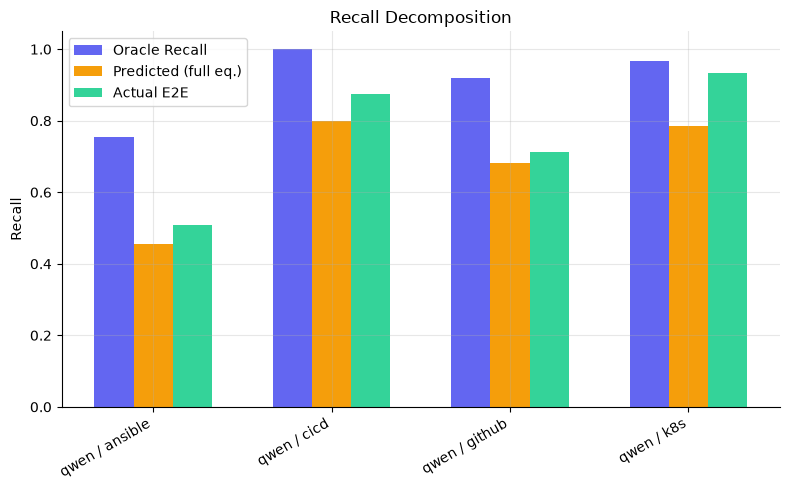

In [8]:
if not decomp.empty:
    plot_df = decomp.copy()
    plot_df["label"] = plot_df["model"] + " / " + plot_df["domain"]

    fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 1.5), 5))
    x = range(len(plot_df))
    w = 0.22

    ax.bar([i - w for i in x], plot_df["oracle_recall"], w, label="Oracle Recall", color="#6366f1")

    pred_col = "predicted_full" if plot_df["predicted_full"].notna().all() else "predicted_simple"
    pred_label = "Predicted (full eq.)" if pred_col == "predicted_full" else "Predicted (simple)"
    ax.bar(list(x), plot_df[pred_col], w, label=pred_label, color="#f59e0b")

    if plot_df["actual_recall"].notna().any():
        ax.bar([i + w for i in x], plot_df["actual_recall"], w, label="Actual E2E", color="#34d399")

    ax.set_xticks(list(x))
    ax.set_xticklabels(plot_df["label"], rotation=30, ha="right")
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_title("Recall Decomposition")
    plt.tight_layout()
    plt.show()

## 4. Type Prediction Analysis

Where is the LLM struggling — source types, target types, or both?

In [9]:
type_df = df[df["strategy"] == TYPE_KEY].copy()

if not type_df.empty:
    display(type_df[["model", "domain", "source_accuracy", "target_accuracy", "exact_match_accuracy"]].rename(
        columns={"source_accuracy": "Source Acc", "target_accuracy": "Target Acc", "exact_match_accuracy": "Exact Match"}
    ))

    mean_src = type_df["source_accuracy"].mean()
    mean_tgt = type_df["target_accuracy"].mean()
    if mean_src < mean_tgt - 0.05:
        print(f"\nSource prediction ({mean_src:.2f}) is harder than target ({mean_tgt:.2f}).")
    elif mean_tgt < mean_src - 0.05:
        print(f"\nTarget prediction ({mean_tgt:.2f}) is harder than source ({mean_src:.2f}).")
    else:
        print(f"\nSource ({mean_src:.2f}) and target ({mean_tgt:.2f}) accuracy are comparable.")
else:
    print(f"No {TYPE_KEY} strategy found.")

,model,domain,Source Acc,Target Acc,Exact Match
1,qwen,ansible,0.600,0.667,0.533
8,qwen,cicd,0.538,0.731,0.462
15,qwen,github,0.667,0.867,0.600
22,qwen,k8s,0.800,0.800,0.640



Source prediction (0.65) is harder than target (0.77).


### 4.1 Type Accuracy by Query Category

In [10]:
type_queries = qdf[qdf["strategy"] == TYPE_KEY].copy()

if not type_queries.empty and "source_correct" in type_queries.columns:
    cat_acc = type_queries.groupby("category").agg(
        n=("source_correct", "count"),
        source_acc=("source_correct", "mean"),
        target_acc=("target_correct", "mean"),
        exact=("both_correct", "mean"),
    )
    display(cat_acc)
else:
    print("Per-query type accuracy fields not available.")

,n,source_acc,target_acc,exact
category,,,,
ambiguous,12,0.500,0.167,0.167
clean,40,0.800,0.950,0.800
multihop,21,0.571,0.952,0.571
multipath,6,0.333,0.667,0.167
noisy,15,0.533,0.800,0.533
synonym,17,0.706,0.529,0.412


## 5. Error Analysis

Where does the graph fail? Is it wrong types or missing paths?

In [11]:
e2e_queries = qdf[qdf["strategy"] == E2E_KEY].copy()

if not e2e_queries.empty and "predicted_source" in e2e_queries.columns:
    e2e_queries["types_correct"] = (
        (e2e_queries["predicted_source"] == e2e_queries["expected_source"]) &
        (e2e_queries["predicted_target"] == e2e_queries["expected_target"])
    )
    e2e_queries["path_found"] = e2e_queries.get("path_found", e2e_queries.get("path_length", pd.Series(dtype=float)).notna())

    failures = e2e_queries[e2e_queries["recall"] == 0].copy()
    if not failures.empty:
        n_wrong_types = (~failures["types_correct"]).sum()
        n_correct_types = failures["types_correct"].sum()
        print(f"Queries with recall=0: {len(failures)}")
        print(f"  Due to wrong types:    {n_wrong_types}")
        print(f"  Despite correct types: {n_correct_types} (graph coverage gap)")
    else:
        print("No queries with recall=0.")

    # Recall breakdown by type correctness
    print("\nRecall by type correctness:")
    breakdown = e2e_queries[e2e_queries["recall"] >= 0].groupby("types_correct")["recall"].agg(["mean", "count"])
    breakdown.index = ["Wrong types", "Correct types"]
    display(breakdown)
else:
    print(f"No per-query data for {E2E_KEY}, or missing type prediction fields.")

Queries with recall=0: 13
  Due to wrong types:    10
  Despite correct types: 3 (graph coverage gap)

Recall by type correctness:


,mean,count
Wrong types,0.333,27
Correct types,0.912,59


### 5.1 Graph Regressions

Queries where the baseline gets non-zero recall but the graph gets zero.

In [12]:
bl_queries = qdf[qdf["strategy"] == BASELINE_KEY].copy()

if not e2e_queries.empty and not bl_queries.empty:
    bl_ok = set(bl_queries[bl_queries["recall"] > 0]["id"].unique())
    graph_fail = set(e2e_queries[e2e_queries["recall"] <= 0]["id"].unique())
    regressions = bl_ok & graph_fail

    if regressions:
        print(f"{len(regressions)} regression(s) — baseline succeeds but graph fails:")
        reg_detail = e2e_queries[e2e_queries["id"].isin(regressions)]
        show_cols = ["model", "domain", "id", "category"]
        if "predicted_source" in reg_detail.columns:
            show_cols += ["expected_source", "expected_target", "predicted_source", "predicted_target"]
        display(reg_detail[show_cols])
    else:
        print("No regressions — graph never loses a query that baseline gets right.")
else:
    print("Cannot compute regressions — missing baseline or e2e per-query data.")

18 regression(s) — baseline succeeds but graph fails:


,model,domain,id,category,expected_source,expected_target,predicted_source,predicted_target
154,qwen,ansible,group_hosts,clean,Group,Host,Group,Host
158,qwen,ansible,add_host_write,clean,Inventory,Host,Host,Inventory
161,qwen,ansible,ambiguous_playbook,ambiguous,Playbook,Task,Playbook,PlaybookVars
167,qwen,ansible,multihop_implicit_logs,multihop,Playbook,RunLog,Job,JobLog
169,qwen,ansible,synonym_machines,synonym,Inventory,Host,Inventory,Host
178,qwen,ansible,multipath_host_vars,multipath,Host,HostVars,Group,GroupVars
179,qwen,ansible,multipath_deploy_tasks,multipath,Playbook,Task,JobTemplate,Task
349,qwen,cicd,describe_model,clean,ModelName,DataModelDescription,DataModelDescription,ModelName
353,qwen,cicd,multihop_artifact_sbom,multihop,Product,SBOMList,Accelerator,SBOMList
357,qwen,cicd,multihop_sha_digest,multihop,Product,SHADigest,AcceleratorList,SHADigest


## 6. Strategy Comparison

How does graph compare to baselines across all metrics?

In [13]:
compare_strategies = [BASELINE_KEY, BASELINE_TOOLS_KEY, "retrieval", E2E_KEY, ORACLE_KEY]
compare_df = df[df["strategy"].isin(compare_strategies)].copy()

if not compare_df.empty:
    metrics = ["f1", "precision", "recall", "hallucinated", "pruning"]
    pivot = compare_df.pivot_table(
        index=["model", "domain"],
        columns="strategy",
        values=metrics,
    )

    for metric in ["f1", "recall", "precision"]:
        if metric in pivot.columns.get_level_values(0):
            sub = pivot[metric].reindex(columns=[s for s in compare_strategies if s in pivot[metric].columns])
            print(f"\n{metric.upper()}:")
            display(sub)


F1:


strategy       baseline  baseline-tools  retrieval  graph  graph-perfect
model domain                                                            
qwen  ansible     0.502           0.454      0.613  0.536          0.774
      cicd        0.515           0.443      0.660  0.844          1.000
      github      0.615           0.448      0.500  0.678          0.813
      k8s         0.642           0.517      0.590  0.953          0.972


RECALL:


strategy       baseline  baseline-tools  retrieval  graph  graph-perfect
model domain                                                            
qwen  ansible     0.584           0.409      0.566  0.508          0.754
      cicd        0.625           0.430      0.650  0.875          1.000
      github      0.792           0.424      0.601  0.712          0.920
      k8s         0.741           0.512      0.561  0.933          0.967


PRECISION:


strategy       baseline  baseline-tools  retrieval  graph  graph-perfect
model domain                                                            
qwen  ansible     0.489           0.567      0.741  0.594          0.807
      cicd        0.491           0.480      0.697  0.870          1.000
      github      0.555           0.540      0.478  0.708          0.761
      k8s         0.628           0.654      0.667  1.000          0.981

In [14]:
# Delta vs baseline
if not compare_df.empty and BASELINE_KEY in compare_df["strategy"].values:
    bl = compare_df[compare_df["strategy"] == BASELINE_KEY].set_index(["model", "domain"])
    delta_rows = []
    for strat in [s for s in compare_strategies if s != BASELINE_KEY]:
        strat_df = compare_df[compare_df["strategy"] == strat].set_index(["model", "domain"])
        for idx in strat_df.index:
            if idx in bl.index:
                delta_rows.append({
                    "model": idx[0], "domain": idx[1], "strategy": strat,
                    "f1_delta": strat_df.loc[idx, "f1"] - bl.loc[idx, "f1"],
                    "recall_delta": strat_df.loc[idx, "recall"] - bl.loc[idx, "recall"],
                    "precision_delta": strat_df.loc[idx, "precision"] - bl.loc[idx, "precision"],
                })
    if delta_rows:
        delta_df = pd.DataFrame(delta_rows)
        print("\nDelta vs baseline:")
        display(delta_df.pivot_table(index=["model", "domain"], columns="strategy", values="f1_delta"))

        # Conditional claims
        e2e_deltas = delta_df[delta_df["strategy"] == E2E_KEY]
        n_wins = (e2e_deltas["f1_delta"] > 0).sum()
        n_total = len(e2e_deltas)
        print(f"\nGraph improves over baseline in {n_wins}/{n_total} model/domain combos.")


Delta vs baseline:


strategy       baseline-tools  graph  graph-perfect  retrieval
model domain                                                  
qwen  ansible          -0.048  0.033          0.272      0.111
      cicd             -0.072  0.330          0.485      0.146
      github           -0.167  0.063          0.198     -0.115
      k8s              -0.125  0.311          0.330     -0.052


Graph improves over baseline in 4/4 model/domain combos.


## 7. Pruning & Token Efficiency

How much does graph reduce the search space and token cost?

In [15]:
eff_strategies = [BASELINE_KEY, BASELINE_TOOLS_KEY, "retrieval", E2E_KEY]
eff_df = df[df["strategy"].isin(eff_strategies)].copy()

if not eff_df.empty:
    print("Average prompt tokens by strategy:")
    tok_pivot = eff_df.pivot_table(
        index=["model", "domain"], columns="strategy",
        values="avg_prompt_tokens",
    ).reindex(columns=[s for s in eff_strategies if s in eff_df["strategy"].values])
    display(tok_pivot)

    print("\nPruning (% of tools filtered):")
    prune_pivot = eff_df.pivot_table(
        index=["model", "domain"], columns="strategy",
        values="pruning",
    ).reindex(columns=[s for s in eff_strategies if s in eff_df["strategy"].values])
    display(prune_pivot)

Average prompt tokens by strategy:


strategy       baseline  baseline-tools  retrieval   graph
model domain                                              
qwen  ansible  1461.300        4973.300    202.067 555.300
      cicd      851.231        2631.231    219.962 871.231
      github   1804.467        6111.467    205.400 522.467
      k8s      1962.840        6323.840    207.880 491.840


Pruning (% of tools filtered):


strategy       baseline  baseline-tools  retrieval  graph
model domain                                             
qwen  ansible     0.975           0.990      0.983  0.988
      cicd        0.911           0.982      0.962  0.979
      github      0.973           0.991      0.983  0.986
      k8s         0.976           0.990      0.985  0.987

## 8. Per-Category Performance

Which query categories benefit most from graph-based tool selection?

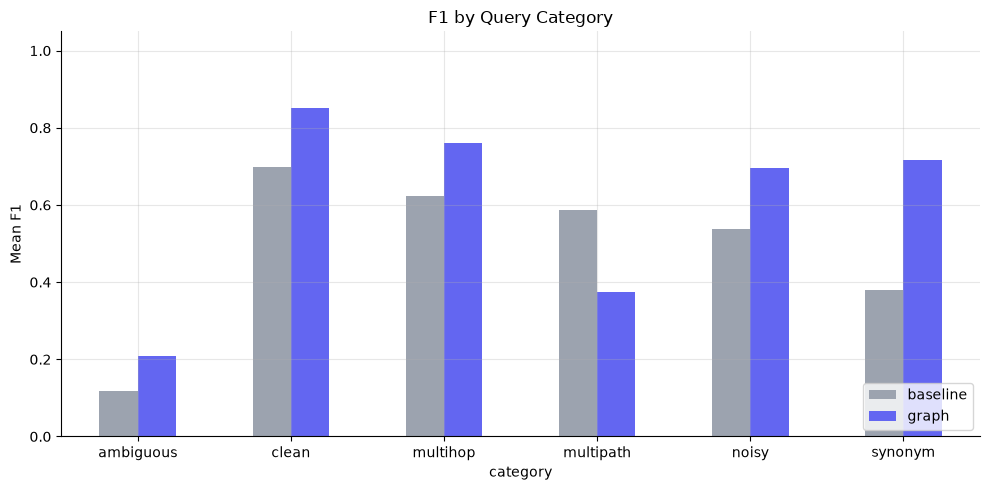

strategy,baseline,graph
category,,
ambiguous,0.118,0.210
clean,0.700,0.851
multihop,0.623,0.761
multipath,0.586,0.375
noisy,0.539,0.697
synonym,0.379,0.717


In [16]:
cat_strategies = [BASELINE_KEY, E2E_KEY]
cat_data = qdf[qdf["strategy"].isin(cat_strategies) & (qdf["recall"] >= 0)].copy()

if not cat_data.empty and "category" in cat_data.columns:
    cat_f1 = cat_data.groupby(["category", "strategy"])["f1"].mean().unstack("strategy")
    cat_f1 = cat_f1.reindex(columns=[s for s in cat_strategies if s in cat_f1.columns])

    fig, ax = plt.subplots(figsize=(10, 5))
    cat_f1.plot.bar(ax=ax, rot=0, color=["#9ca3af", "#6366f1"])
    ax.set_ylabel("Mean F1")
    ax.set_ylim(0, 1.05)
    ax.set_title("F1 by Query Category")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    display(cat_f1)
else:
    print("No category data available.")

## 9. Overview Heatmap

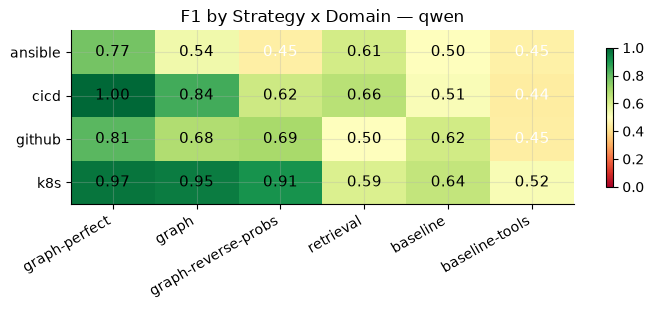

In [17]:
all_strategies = [ORACLE_KEY, E2E_KEY, "graph-reverse-probs", "retrieval", BASELINE_KEY, BASELINE_TOOLS_KEY]
heat_df = df[df["strategy"].isin(all_strategies)].copy()

if not heat_df.empty:
    for model in models:
        sub = heat_df[heat_df["model"] == model]
        if sub.empty:
            continue
        piv = sub.pivot_table(index="domain", columns="strategy", values="f1")
        piv = piv.reindex(columns=[s for s in all_strategies if s in piv.columns])

        fig, ax = plt.subplots(figsize=(max(6, len(piv.columns) * 1.2), max(3, len(piv) * 0.8)))
        im = ax.imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns, rotation=30, ha="right")
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels(piv.index)

        for i in range(len(piv.index)):
            for j in range(len(piv.columns)):
                val = piv.values[i, j]
                if not pd.isna(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            color="black" if val > 0.5 else "white", fontsize=11)

        ax.set_title(f"F1 by Strategy x Domain — {model}")
        plt.colorbar(im, ax=ax, shrink=0.8)
        plt.tight_layout()
        plt.show()